In [3]:
import cv2 as cv2
import numpy as np
import matplotlib.pyplot as plt

In [16]:
def segment_image(path):
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Image not found: {path}")
    else:

        image = 255 - image

        _, thresh = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])

        digits = []
        for c in contours:
            x, y, w, h = cv2.boundingRect(c)

            # Skip small noise
            if w < 10 or h < 10:
                continue

            # 5️⃣ Crop and resize
            digit = thresh[y:y+h, x:x+w]
            digit = cv2.resize(digit, (28, 28))
            digits.append(digit)


            cv2.rectangle(image, (x, y), (x+w, y+h), 128, 1)

        plt.figure(figsize=(10, 3))
        plt.imshow(image, cmap='gray')
        plt.title(f"Found {len(digits)} digits")
        plt.axis('off')
        plt.show()

        return digits


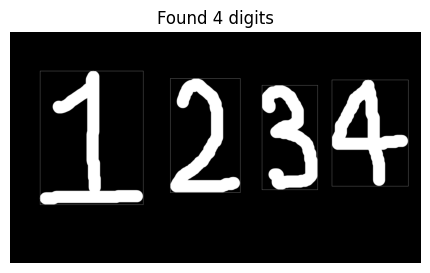

In [17]:
path = 'input/1234.png'
digits = segment_image(path)